Columnas en df_backtest: ['close', 'high', 'low', 'open', 'price', 'timestamp', 'volume']


,close,high,low,open,price,timestamp,volume
0,1823.96,1823.97,1822.55,1823.57,1823.96,1746484380000.0,152.7713
1,1822.6,1823.97,1822.20,1823.97,1822.60,1746484440000.0,182.9051
2,1823.99,1823.99,1822.60,1822.60,1823.99,1746484500000.0,197.1422
3,1824.48,1824.48,1823.68,1824.00,1824.48,1746484560000.0,179.0136
4,1824.65,1824.81,1824.00,1824.48,1824.65,1746484620000.0,110.4405


KeyError: 'saldo_virtual'

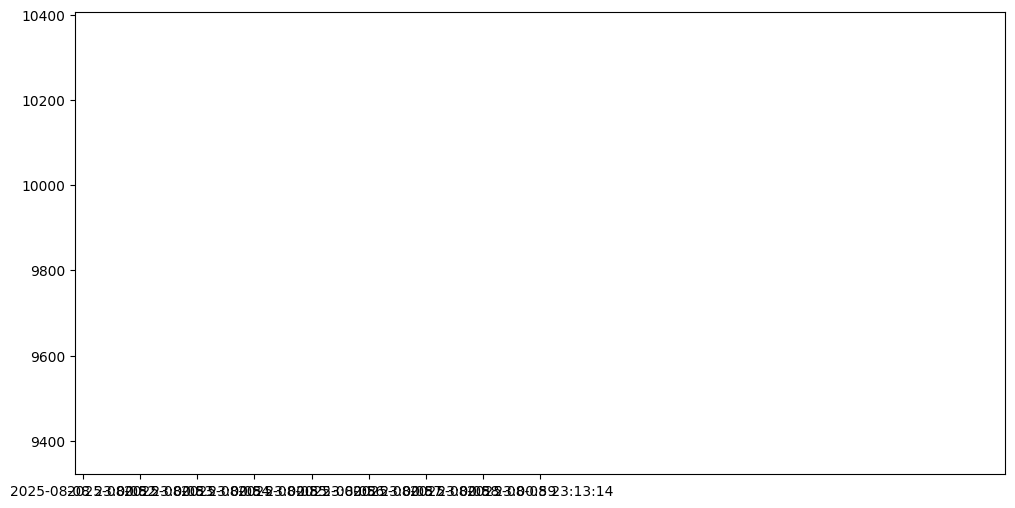

In [1]:
# Análisis comparativo: Paper Trading vs Backtesting

import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# --- Carga de archivos principales ---
archivos = {
    "papertrading_BTCUSDT.csv": "../data/papertrading/papertrading_BTCUSDT.csv",
    "estado_papertrading.json": "../data/papertrading/estado_papertrading.json",
    "historial_trading.csv": "../data/historiales/historial_trading.csv",
    "nodateparametros_seleccionadosnodate.json": "../data/backtesting/nodateparametros_seleccionadosnodate.json"
}

def cargar_csv(ruta):
    if os.path.exists(ruta):
        return pd.read_csv(ruta)
    else:
        print(f"⚠️ El archivo {ruta} no existe.")
        return pd.DataFrame()

def cargar_json(ruta):
    if os.path.exists(ruta):
        with open(ruta, encoding="utf-8") as f:
            return json.load(f)
    else:
        print(f"⚠️ El archivo {ruta} no existe.")
        return {}

# --- Cargar datos Paper Trading ---
df_paper = cargar_csv(archivos["papertrading_BTCUSDT.csv"])
estado_paper = cargar_json(archivos["estado_papertrading.json"])

# --- Cargar datos Backtesting ---
df_backtest = cargar_csv(archivos["historial_trading.csv"])
parametros_backtest = cargar_json(archivos["nodateparametros_seleccionadosnodate.json"])

print("Columnas en df_backtest:", df_backtest.columns.tolist())
display(df_backtest.head())

# --- Gráfico comparativo de saldo virtual ---
plt.figure(figsize=(12, 6))
if not df_paper.empty:
    plt.plot(df_paper["timestamp"], df_paper["saldo_virtual"], label="Paper Trading")
if not df_backtest.empty:
    plt.plot(df_backtest["timestamp"], df_backtest["saldo_virtual"], label="Backtesting")
plt.xticks(rotation=45)
plt.title("Comparativa de saldo virtual: Paper Trading vs Backtesting")
plt.xlabel("Fecha")
plt.ylabel("Saldo USDT")
plt.legend()
plt.tight_layout()
plt.show()

# --- Métricas comparativas ---
def resumen_metricas(df, nombre):
    if df.empty:
        return pd.Series(name=nombre)
    return pd.Series({
        "Operaciones": len(df),
        "Saldo inicial": df["saldo_virtual"].iloc[0] if "saldo_virtual" in df else None,
        "Saldo final": df["saldo_virtual"].iloc[-1] if "saldo_virtual" in df else None,
        "Ganancia total": (df["saldo_virtual"].iloc[-1] - df["saldo_virtual"].iloc[0]) if "saldo_virtual" in df else None
    }, name=nombre)

resumen_paper = resumen_metricas(df_paper, "Paper Trading")
resumen_backtest = resumen_metricas(df_backtest, "Backtesting")

comparativo = pd.concat([resumen_paper, resumen_backtest], axis=1)
print("Resumen comparativo de métricas principales:")
display(comparativo)

# --- Mostrar últimas operaciones ---
from IPython.display import display

print("Últimas operaciones Paper Trading:")
if not df_paper.empty:
    display(df_paper.tail(10))

print("Últimas operaciones Backtesting:")
if not df_backtest.empty:
    display(df_backtest.tail(10))

